# 🛒 SecondPrice — Tahap 1: Eksplorasi & Preprocessing
**EDA dasar + preprocessing teks**

## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 2. Load Dataset

Upload file `train.tsv` ke Colab terlebih dahulu, atau mount Google Drive.

In [2]:
# Jika file ada di direktori yang sama dengan notebook:
TRAIN_PATH = 'train.tsv'

# Jika mount Google Drive, ganti path di atas menjadi:
# from google.colab import drive
# drive.mount('/content/drive')
# TRAIN_PATH = '/content/drive/MyDrive/mercari/train.tsv'

# Load dengan nrows dulu untuk cek struktur (lebih cepat)
df_sample = pd.read_csv(TRAIN_PATH, sep='\t', nrows=5)
print('Kolom yang tersedia:')
print(df_sample.columns.tolist())
print()
df_sample

Kolom yang tersedia:
['train_id', 'name', 'item_condition_id', 'category_name', 'brand_name', 'price', 'shipping', 'item_description']



,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & Parts,Razer,52.0,0,This keyboard is in great condition and works like it came out of the box. A...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hole in the back! The pale pink i...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm] each. Stand about a foot high...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


In [3]:
# Load subset 200.000 baris (cukup untuk proyek, hemat RAM Colab)
NROWS = 200_000

df = pd.read_csv(TRAIN_PATH, sep='\t', nrows=NROWS)
print(f'✅ Dataset loaded: {df.shape[0]:,} baris x {df.shape[1]} kolom')

✅ Dataset loaded: 200,000 baris x 8 kolom


## 3. Eksplorasi Awal (EDA Dasar)

In [4]:
# Info umum
print('=== INFO DATASET ===')
df.info()
print()

print('=== 5 BARIS PERTAMA ===')
df.head()

=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   train_id           200000 non-null  int64  
 1   name               200000 non-null  str    
 2   item_condition_id  200000 non-null  int64  
 3   category_name      199148 non-null  str    
 4   brand_name         114600 non-null  str    
 5   price              200000 non-null  float64
 6   shipping           200000 non-null  int64  
 7   item_description   200000 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 12.2 MB

=== 5 BARIS PERTAMA ===


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & Parts,Razer,52.0,0,This keyboard is in great condition and works like it came out of the box. A...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hole in the back! The pale pink i...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm] each. Stand about a foot high...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


In [5]:
# Cek missing values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
print(missing_df[missing_df['Jumlah Missing'] > 0])

=== MISSING VALUES ===
               Jumlah Missing  Persentase (%)
category_name             852            0.43
brand_name              85400           42.70


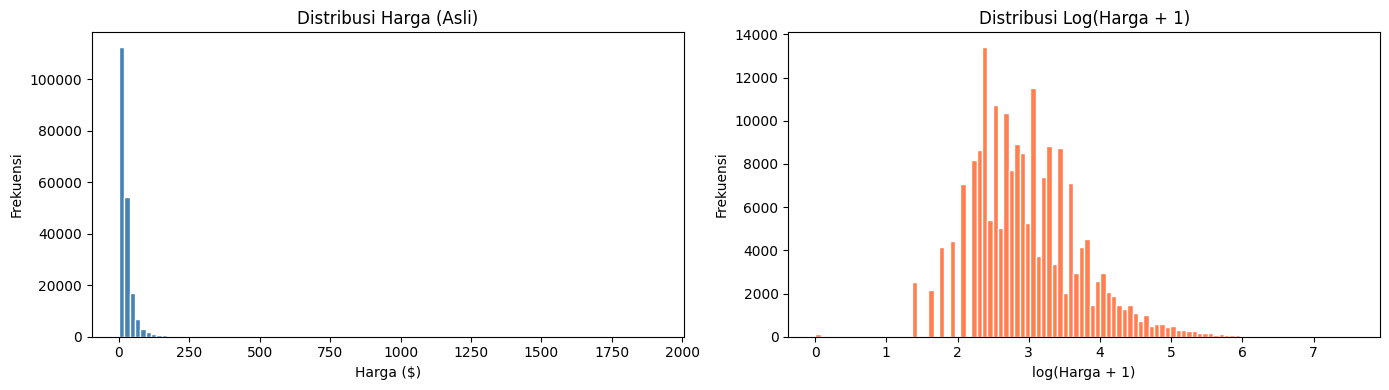

Harga min   : $0.00
Harga maks  : $1909.00
Harga median: $17.00
Harga rata2 : $26.74


In [6]:
# Distribusi harga
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribusi harga asli
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Harga (Asli)')
axes[0].set_xlabel('Harga ($)')
axes[0].set_ylabel('Frekuensi')

# Distribusi log harga (lebih normal)
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=100, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Log(Harga + 1)')
axes[1].set_xlabel('log(Harga + 1)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Harga min   : ${df["price"].min():.2f}')
print(f'Harga maks  : ${df["price"].max():.2f}')
print(f'Harga median: ${df["price"].median():.2f}')
print(f'Harga rata2 : ${df["price"].mean():.2f}')

In [7]:
# Eksplorasi kategori
print('=== TOP 15 KATEGORI ===')
print(df['category_name'].value_counts().head(15))
print()
print(f'Total kategori unik: {df["category_name"].nunique()}')

=== TOP 15 KATEGORI ===
category_name
Women/Athletic Apparel/Pants, Tights, Leggings                 8003
Women/Tops & Blouses/T-Shirts                                  6218
Beauty/Makeup/Face                                             4643
Beauty/Makeup/Lips                                             4076
Electronics/Video Games & Consoles/Games                       3484
Electronics/Cell Phones & Accessories/Cases, Covers & Skins    3388
Beauty/Makeup/Eyes                                             3384
Women/Underwear/Bras                                           2985
Women/Tops & Blouses/Tank, Cami                                2774
Women/Tops & Blouses/Blouse                                    2761
Women/Dresses/Above Knee, Mini                                 2712
Women/Jewelry/Necklaces                                        2686
Women/Athletic Apparel/Shorts                                  2664
Beauty/Makeup/Makeup Palettes                                  2638
Beauty/Fra

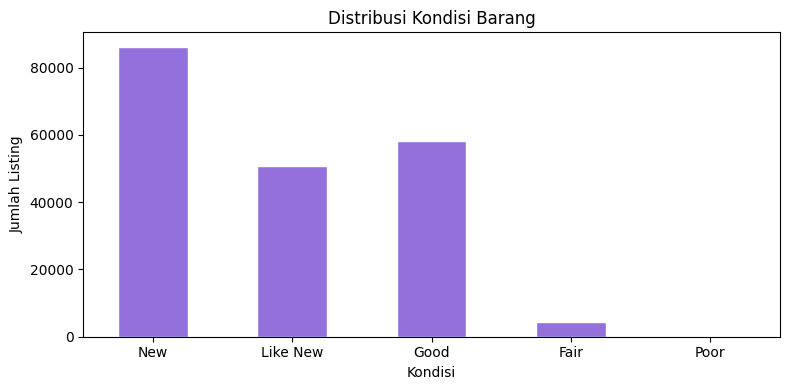

In [8]:
# Distribusi kondisi barang
condition_labels = {
    1: 'New',
    2: 'Like New',
    3: 'Good',
    4: 'Fair',
    5: 'Poor'
}

condition_counts = df['item_condition_id'].value_counts().sort_index()
condition_counts.index = [condition_labels[i] for i in condition_counts.index]

plt.figure(figsize=(8, 4))
condition_counts.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Distribusi Kondisi Barang')
plt.xlabel('Kondisi')
plt.ylabel('Jumlah Listing')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('condition_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Preprocessing

Langkah-langkah:
1. Hapus baris dengan harga = 0 (tidak valid)
2. Isi nilai kosong
3. Pisah kolom `category_name` menjadi 3 level
4. Bersihkan teks deskripsi
5. Tambah kolom `log_price` sebagai target

In [9]:
print(f'Jumlah baris sebelum filter: {len(df):,}')

# Hapus harga = 0 (tidak valid untuk dijual)
df = df[df['price'] > 0].copy()

print(f'Jumlah baris setelah filter harga > 0: {len(df):,}')

Jumlah baris sebelum filter: 200,000
Jumlah baris setelah filter harga > 0: 199,894


In [10]:
# Isi nilai kosong
df['brand_name']       = df['brand_name'].fillna('No Brand')
df['category_name']    = df['category_name'].fillna('Other/Other/Other')
df['item_description'] = df['item_description'].fillna('')

# Cek ulang missing values
print('Missing values setelah pengisian:')
print(df.isnull().sum())

Missing values setelah pengisian:
train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
dtype: int64


In [11]:
# Pisah category_name menjadi 3 level
# Contoh: "Women/Tops & Blouses/T-Shirts" → cat_1, cat_2, cat_3

def split_category(cat_str):
    parts = str(cat_str).split('/')
    # Pastikan selalu 3 elemen
    while len(parts) < 3:
        parts.append('Other')
    return parts[0], parts[1], parts[2]

df[['cat_1', 'cat_2', 'cat_3']] = df['category_name'].apply(
    lambda x: pd.Series(split_category(x))
)

print('Contoh hasil split kategori:')
df[['category_name', 'cat_1', 'cat_2', 'cat_3']].head(5)

Contoh hasil split kategori:


,category_name,cat_1,cat_2,cat_3
0,Men/Tops/T-shirts,Men,Tops,T-shirts
1,Electronics/Computers & Tablets/Components & Parts,Electronics,Computers & Tablets,Components & Parts
2,Women/Tops & Blouses/Blouse,Women,Tops & Blouses,Blouse
3,Home/Home Décor/Home Décor Accents,Home,Home Décor,Home Décor Accents
4,Women/Jewelry/Necklaces,Women,Jewelry,Necklaces


In [12]:
# Bersihkan teks deskripsi
def clean_text(text):
    text = str(text).lower()                        # lowercase
    text = re.sub(r'[^a-z0-9\s]', ' ', text)       # hapus karakter khusus
    text = re.sub(r'\s+', ' ', text).strip()        # normalize spasi
    return text

df['name_clean']        = df['name'].apply(clean_text)
df['description_clean'] = df['item_description'].apply(clean_text)

# Gabungkan nama + deskripsi sebagai teks utama
df['text_combined'] = df['name_clean'] + ' ' + df['description_clean']

print('Contoh teks sebelum dan sesudah cleaning:')
for i in range(2):
    print(f'\n[Baris {i}]')
    print(f'  Asli     : {df["name"].iloc[i]}')
    print(f'  Bersih   : {df["name_clean"].iloc[i]}')

Contoh teks sebelum dan sesudah cleaning:

[Baris 0]
  Asli     : MLB Cincinnati Reds T Shirt Size XL
  Bersih   : mlb cincinnati reds t shirt size xl

[Baris 1]
  Asli     : Razer BlackWidow Chroma Keyboard
  Bersih   : razer blackwidow chroma keyboard


In [13]:
# Tambah kolom log_price sebagai target variabel
# log1p(x) = log(x + 1), aman untuk harga kecil
df['log_price'] = np.log1p(df['price'])

print('Kolom log_price berhasil ditambahkan.')
print(df[['price', 'log_price']].describe().round(3))

Kolom log_price berhasil ditambahkan.
            price   log_price
count  199894.000  199894.000
mean       26.759       2.981
std        38.730       0.746
min         3.000       1.386
25%        10.000       2.398
50%        17.000       2.890
75%        29.000       3.401
max      1909.000       7.555


## 5. Ringkasan Kolom Final

In [14]:
# Pilih kolom yang relevan untuk tahap selanjutnya
FINAL_COLS = [
    'train_id',
    'name',
    'name_clean',
    'item_condition_id',
    'brand_name',
    'cat_1', 'cat_2', 'cat_3',
    'shipping',
    'text_combined',
    'price',
    'log_price'
]

df_clean = df[FINAL_COLS].copy()

print(f'Shape dataset bersih: {df_clean.shape}')
print()
df_clean.head(3)

Shape dataset bersih: (199894, 12)



,train_id,name,name_clean,item_condition_id,brand_name,cat_1,cat_2,cat_3,shipping,text_combined,price,log_price
0,0,MLB Cincinnati Reds T Shirt Size XL,mlb cincinnati reds t shirt size xl,3,No Brand,Men,Tops,T-shirts,1,mlb cincinnati reds t shirt size xl no description yet,10.0,2.397895
1,1,Razer BlackWidow Chroma Keyboard,razer blackwidow chroma keyboard,3,Razer,Electronics,Computers & Tablets,Components & Parts,0,razer blackwidow chroma keyboard this keyboard is in great condition and wor...,52.0,3.970292
2,2,AVA-VIV Blouse,ava viv blouse,1,Target,Women,Tops & Blouses,Blouse,1,ava viv blouse adorable top with a hint of lace and a key hole in the back t...,10.0,2.397895


## 6. Simpan Hasil Preprocessing

In [15]:
OUTPUT_PATH = 'train_clean.csv'
df_clean.to_csv(OUTPUT_PATH, index=False)

print(f'✅ File tersimpan: {OUTPUT_PATH}')
print(f'   Total baris  : {len(df_clean):,}')
print(f'   Total kolom  : {df_clean.shape[1]}')
print()
print('Kolom yang tersimpan:')
for col in df_clean.columns:
    print(f'  - {col}')

✅ File tersimpan: train_clean.csv
   Total baris  : 199,894
   Total kolom  : 12

Kolom yang tersimpan:
  - train_id
  - name
  - name_clean
  - item_condition_id
  - brand_name
  - cat_1
  - cat_2
  - cat_3
  - shipping
  - text_combined
  - price
  - log_price


---
## ✅ Checklist Tahap 1

- [x] Dataset berhasil di-load
- [x] Missing values ditangani
- [x] Harga tidak valid (= 0) dihapus
- [x] Kategori dipecah menjadi 3 level
- [x] Teks nama & deskripsi dibersihkan
- [x] Kolom `log_price` ditambahkan sebagai target
- [x] Dataset bersih disimpan ke `train_clean.csv`

## ➡️ Tahap Selanjutnya (Notebook 02)

- Membangun struktur graph: node produk, merek, dan kategori
- Membuat edge antar node
- Encode fitur node untuk input GNN